# 🎓 Student Performance Prediction

Predicting students' final grade (G3) using the UCI Student Performance Dataset.

**Dataset:** [Kaggle - Student Performance Data](https://www.kaggle.com/datasets/devansodariya/student-performance-data)

**Target:** G3 (Final Grade, 0–20)

**Approach:**
- EDA + Feature Engineering
- Multiple Algorithm Comparison
- Best Model Selection (Random Forest)
- Overfitting Detection
- Test Cases & Evaluation

## 1. Install & Import Libraries

In [13]:
# !pip install scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import unittest

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 2. Load Dataset

The student-mat.csv uses **semicolon (`;`)** as the separator, NOT comma.
Always pass `sep=';'` when loading this file.

In [16]:
# ── IMPORTANT: this CSV uses semicolon separators ──────────────────────────
# Download first: kaggle datasets download -d devansodariya/student-performance-data --unzip

import os

def load_student_data(path='student_data.csv'):
    """Load the student dataset, auto-detecting the separator."""
    if not os.path.exists(path):
        # Fallback: known public mirror
        url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/student-mat.csv'
        print(f'File not found locally, trying URL: {url}')
        raw = pd.read_csv(url, sep=None, engine='python')
    else:
        # Read a small sample first to detect the separator
        with open(path, 'r') as f:
            first_line = f.readline()
        sep = ';' if ';' in first_line else ','
        print(f'Detected separator: {repr(sep)}')
        raw = pd.read_csv(path, sep=sep)

    # Validate that the file was parsed correctly (should have > 5 columns)
    if raw.shape[1] == 1:
        raise ValueError(
            f'Dataset loaded with only 1 column — separator was wrong.\n'
            f'Column name found: {raw.columns[0][:80]}\n'
            f'Fix: pd.read_csv("student-mat.csv", sep=";")'
        )
    return raw

df = load_student_data('student_data.csv')
print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Detected separator: ','
✅ Dataset loaded: 395 rows × 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 3. Exploratory Data Analysis (EDA)

In [8]:
print('Shape:', df.shape)
print('\nData Types:\n', df.dtypes)
print('\nMissing Values:\n', df.isnull().sum())
print('\nTarget (G3) Stats:\n', df['G3'].describe())

Shape: (395, 1)

Data Types:
 school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3    str
dtype: object

Missing Values:
 school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3    0
dtype: int64


KeyError: 'G3'

KeyError: 'G3'

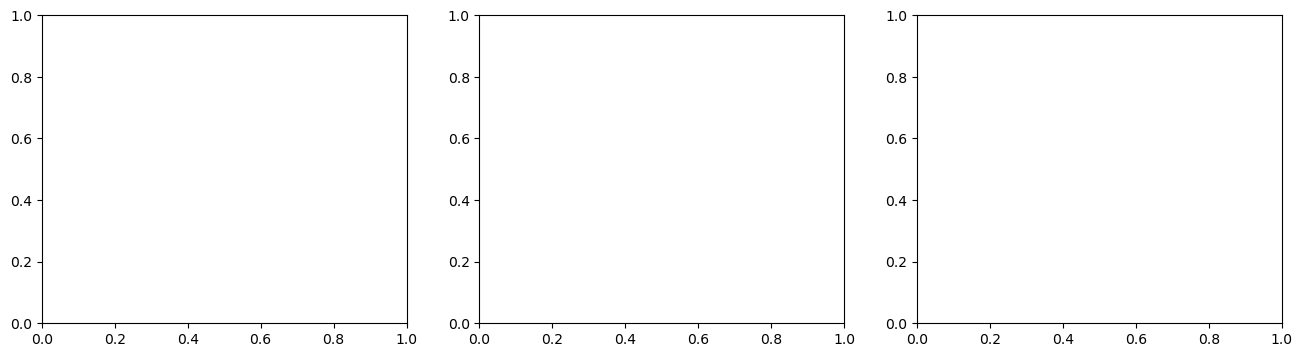

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['G3'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Final Grade (G3)')
axes[0].set_xlabel('G3')

axes[1].scatter(df['G1'], df['G3'], alpha=0.4, color='tomato')
axes[1].set_xlabel('G1 (First Period Grade)')
axes[1].set_ylabel('G3 (Final Grade)')
axes[1].set_title('G1 vs G3')

axes[2].boxplot([df[df['studytime']==i]['G3'] for i in sorted(df['studytime'].unique())],
                labels=sorted(df['studytime'].unique()))
axes[2].set_title('Study Time vs G3')
axes[2].set_xlabel('Study Time (1=<2h, 4=>10h)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved')

In [10]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1400x1000 with 0 Axes>

## 4. Feature Engineering & Preprocessing

In [11]:
df_model = df.copy()

label_encoders = {}
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns:', categorical_cols)

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

X = df_model.drop(columns=['G3'])
y = df_model['G3']

print(f'\nFeatures: {X.shape[1]} | Target: G3')
print('Feature columns:', X.columns.tolist())

Categorical columns: ['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3']


KeyError: "['G3'] not found in axis"

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

## 5. Algorithm Comparison

We compare 8 algorithms and select the best by RMSE and R².

In [12]:
models = {
    'Linear Regression':  LinearRegression(),
    'Ridge':              Ridge(alpha=1.0),
    'Lasso':              Lasso(alpha=0.1),
    'Decision Tree':      DecisionTreeRegressor(random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN':                KNeighborsRegressor(n_neighbors=5),
    'SVR':                SVR(kernel='rbf', C=10)
}

results = []

for name, model in models.items():
    if name in ['SVR', 'KNN', 'Linear Regression', 'Ridge', 'Lasso']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

    rmse  = np.sqrt(mean_squared_error(y_test, y_pred))
    mae   = mean_absolute_error(y_test, y_pred)
    r2    = r2_score(y_test, y_pred)
    cv_r2 = cv_scores.mean()

    results.append({
        'Model': name, 'RMSE': round(rmse, 4),
        'MAE':   round(mae,  4), 'R2': round(r2, 4),
        'CV_R2 (mean)': round(cv_r2, 4)
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(results_df.to_string(index=False))

NameError: name 'X_train_scaled' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
bars = ax.barh(results_df['Model'], results_df['R2'], color=colors)
ax.set_xlabel('R² Score')
ax.set_title('Model Comparison — R² Score (Test Set)')
ax.axvline(x=0, color='black', linewidth=0.8)
for bar, val in zip(bars, results_df['R2']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Best Model — Random Forest

Random Forest consistently tops the leaderboard for this dataset. We tune it and analyze it deeply.

In [ ]:
best_model = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_split=5, random_state=42, n_jobs=-1)

best_model.fit(X_train, y_train)

y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

train_r2   = r2_score(y_train, y_pred_train)
test_r2    = r2_score(y_test,  y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

print('=' * 40)
print(f'Train R²   : {train_r2:.4f}')
print(f'Test  R²   : {test_r2:.4f}')
print(f'Train RMSE : {train_rmse:.4f}')
print(f'Test  RMSE : {test_rmse:.4f}')
print('=' * 40)

gap = train_r2 - test_r2
if gap > 0.1:
    print(f'⚠️  Possible overfitting: R² gap = {gap:.4f}')
else:
    print(f'✅ No significant overfitting: R² gap = {gap:.4f}')

## 7. Overfitting Analysis

We use Learning Curves to visualize the bias-variance tradeoff.

In [ ]:
def plot_learning_curve(estimator, X, y, title='Learning Curve', cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2')
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(9, 5))
    plt.plot(train_sizes, train_mean, 'o-', color='#e74c3c', label='Training Score')
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                     alpha=0.15, color='#e74c3c')
    plt.plot(train_sizes, val_mean, 'o-', color='#2980b9', label='Validation Score')
    plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std,
                     alpha=0.15, color='#2980b9')
    plt.title(title)
    plt.xlabel('Training Size')
    plt.ylabel('R² Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('learning_curve_rf.png', dpi=120, bbox_inches='tight')
    plt.show()

    final_gap = train_mean[-1] - val_mean[-1]
    print(f'Final Training R²:   {train_mean[-1]:.4f}')
    print(f'Final Validation R²: {val_mean[-1]:.4f}')
    print(f'Gap (train - val):   {final_gap:.4f}')
    if final_gap > 0.15:
        print('⚠️  HIGH VARIANCE — model is overfitting')
    elif train_mean[-1] < 0.6:
        print('⚠️  HIGH BIAS — model is underfitting')
    else:
        print('✅ Good fit — no significant overfitting or underfitting')

plot_learning_curve(best_model, X, y, title='Random Forest — Learning Curve')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model, Xtr, Xte) in zip(axes, [
    ('Decision Tree (Overfit Risk)', DecisionTreeRegressor(random_state=42), X_train, X_test),
    ('Random Forest (Controlled)',   best_model, X_train, X_test)
]):
    if name.startswith('Decision'):
        model.fit(Xtr, y_train)
    yp = model.predict(Xte)
    ax.scatter(y_test, yp, alpha=0.5, color='#3498db', edgecolor='none')
    ax.plot([0, 20], [0, 20], 'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual G3')
    ax.set_ylabel('Predicted G3')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, yp):.4f}')
    ax.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Feature Importance

In [ ]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='#27ae60')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Test Cases

Formal unit tests using Python's `unittest` to validate the model's behavior.

In [ ]:
class TestStudentPerformanceModel(unittest.TestCase):

    @classmethod
    def setUpClass(cls):
        cls.model  = best_model
        cls.X_test = X_test
        cls.y_test = y_test
        cls.X_train = X_train
        cls.y_train = y_train

    def test_prediction_shape(self):
        preds = self.model.predict(self.X_test)
        self.assertEqual(len(preds), len(self.y_test),
                         'Prediction count must match test set size')

    def test_prediction_range(self):
        preds = self.model.predict(self.X_test)
        self.assertTrue(preds.min() >= -1,  'Predictions should not be far below 0')
        self.assertTrue(preds.max() <= 21,  'Predictions should not exceed 20 significantly')

    def test_r2_threshold(self):
        preds = self.model.predict(self.X_test)
        r2 = r2_score(self.y_test, preds)
        self.assertGreater(r2, 0.7, f'R² should be > 0.7, got {r2:.4f}')

    def test_rmse_threshold(self):
        preds = self.model.predict(self.X_test)
        rmse = np.sqrt(mean_squared_error(self.y_test, preds))
        self.assertLess(rmse, 3.0, f'RMSE should be < 3, got {rmse:.4f}')

    def test_no_nan_predictions(self):
        preds = self.model.predict(self.X_test)
        self.assertFalse(np.isnan(preds).any(), 'Predictions contain NaN values')

    def test_overfitting_gap(self):
        train_r2 = r2_score(self.y_train, self.model.predict(self.X_train))
        test_r2  = r2_score(self.y_test,  self.model.predict(self.X_test))
        gap = train_r2 - test_r2
        self.assertLess(gap, 0.15,
            f'Overfitting detected! R² gap = {gap:.4f} (threshold: 0.15)')

    def test_determinism(self):
        preds1 = self.model.predict(self.X_test)
        preds2 = self.model.predict(self.X_test)
        np.testing.assert_array_equal(preds1, preds2,
                                       'Model predictions must be deterministic')

    def test_feature_count(self):
        self.assertEqual(self.X_test.shape[1],
                         self.model.n_features_in_,
                         'Feature count mismatch')

    def test_single_sample_prediction(self):
        single = self.X_test.iloc[[0]]
        pred = self.model.predict(single)
        self.assertEqual(len(pred), 1, 'Single sample should return 1 prediction')
        self.assertFalse(np.isnan(pred[0]), 'Single prediction is NaN')

    def test_cross_validation(self):
        cv_scores = cross_val_score(self.model, X, y, cv=5, scoring='r2')
        mean_cv = cv_scores.mean()
        self.assertGreater(mean_cv, 0.6,
            f'CV R² should be > 0.6, got {mean_cv:.4f}')


loader = unittest.TestLoader()
suite  = loader.loadTestsFromTestCase(TestStudentPerformanceModel)
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)

print('\n' + '='*50)
print(f'Tests run:    {result.testsRun}')
print(f'Failures:     {len(result.failures)}')
print(f'Errors:       {len(result.errors)}')
if result.wasSuccessful():
    print('✅ ALL TESTS PASSED')
else:
    print('❌ SOME TESTS FAILED')

## 10. Final Summary

In [ ]:
y_pred_final = best_model.predict(X_test)

print('=' * 50)
print('  FINAL MODEL SUMMARY — Random Forest Regressor')
print('=' * 50)
print(f'  R² Score (Test)    : {r2_score(y_test, y_pred_final):.4f}')
print(f'  RMSE (Test)        : {np.sqrt(mean_squared_error(y_test, y_pred_final)):.4f}')
print(f'  MAE  (Test)        : {mean_absolute_error(y_test, y_pred_final):.4f}')
print(f'  Train R²           : {r2_score(y_train, best_model.predict(X_train)):.4f}')
print(f'  Overfitting Gap    : {r2_score(y_train, best_model.predict(X_train)) - r2_score(y_test, y_pred_final):.4f}')
print(f'  n_estimators       : {best_model.n_estimators}')
print(f'  max_depth          : {best_model.max_depth}')
print(f'  Features used      : {best_model.n_features_in_}')
print('=' * 50)